In [10]:
from files.functions import *
import numpy as np
import pandas as pd
import warnings
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
warnings.filterwarnings('ignore')

# Random Forest Implementation

1. Load and Prepare Data
2. Split into Training and Validation Sets
3. Determine hyperparameters
4. Tune hyperparameters
5. Train the best model
6. SAVE THE MODEL
6. Predict on Validation Set
7. Predict for the next 7 days

## 1. Load and Prepare Data

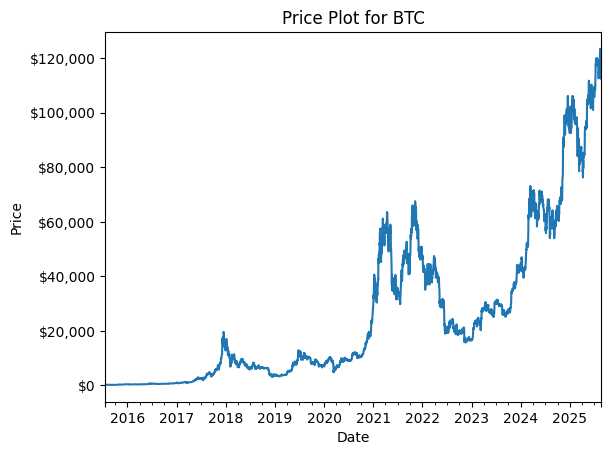

In [11]:
data = pd.read_csv(fullDataPath(COIN))
training_cols = trainingCols('../files/training_columns.txt')
data = dataSetup(data, trainingColPath='../files/training_columns.txt')
data = data[training_cols + ['close']]
data['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

# 2. Split into Training and Validation Sets
### 2a. Normalize the data

In [12]:
X_train_norm, X_test_norm, y_train, y_test, scaler, closeScaler = preprocess_data(data)

# 3. Determine hyperparameters

In [13]:
# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# 4. Tune hyperparameters using GridSearchCV

In [14]:
# Initialize Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Perform grid search with cross-validation
print("Starting hyperparameter tuning...")
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train_norm, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation score: {np.sqrt(-grid_search.best_score_):.6f}")

Starting hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best cross-validation score: 0.329293


# 5. Train the best model

In [15]:
# Get the best model
best_rf = grid_search.best_estimator_

# Train on full training set
print("Training the best Random Forest model...")
best_rf.fit(X_train_norm, y_train)

# Make predictions on test set
y_pred = best_rf.predict(X_test_norm)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Set Performance:")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")

Training the best Random Forest model...
Test Set Performance:
MSE: 0.001716
RMSE: 0.041430
MAE: 0.031015
R²: 0.658606


# 6. Save Models

In [16]:
# Save the trained model and scalers
model_path = f'../models/{COIN}/{COIN}_random_forest_model.pkl'
scaler_path = f'../models/{COIN}/{COIN}_rf_scaler.pkl'
close_scaler_path = f'../models/{COIN}/{COIN}_rf_close_scaler.pkl'

# Save the model
with open(model_path, 'wb') as f:
    pickle.dump(best_rf, f)

# Save the scalers
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

with open(close_scaler_path, 'wb') as f:
    pickle.dump(closeScaler, f)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Close scaler saved to: {close_scaler_path}")

Model saved to: ../models/BTC/BTC_random_forest_model.pkl
Scaler saved to: ../models/BTC/BTC_rf_scaler.pkl
Close scaler saved to: ../models/BTC/BTC_rf_close_scaler.pkl


# 7. Predict on Validation Set and Visualize

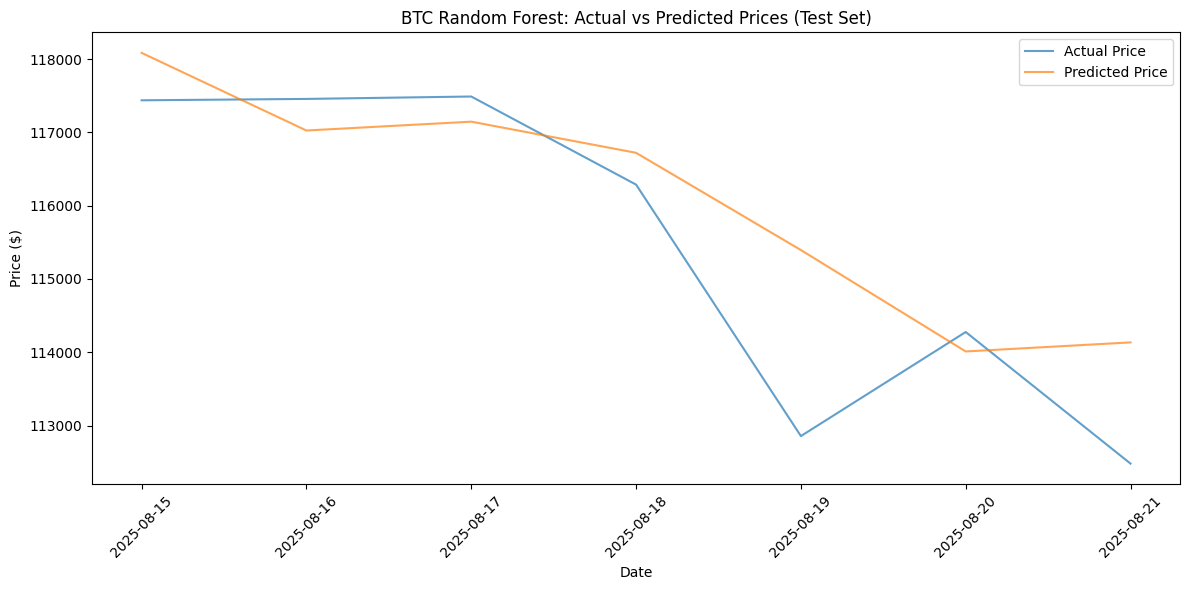

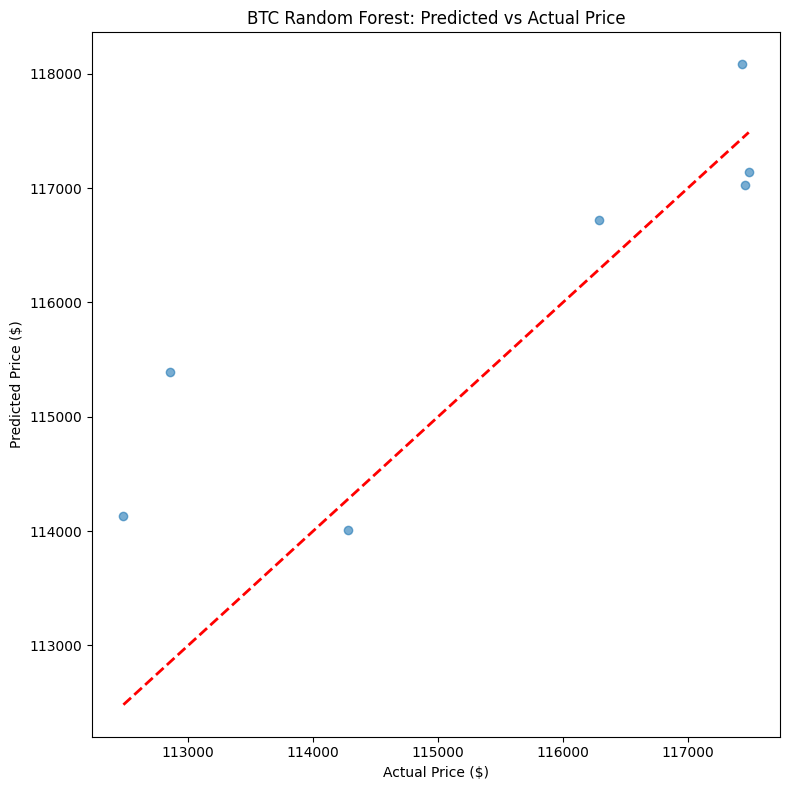

In [17]:
# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
}, index=X_test_norm.index)

# Inverse transform to get actual price values
actual_prices = closeScaler.inverse_transform(predictions_df['actual'].values.reshape(-1, 1)).flatten()
predicted_prices = closeScaler.inverse_transform(predictions_df['predicted'].values.reshape(-1, 1)).flatten()
predictions_df['actual_price'] = actual_prices
predictions_df['predicted_price'] = predicted_prices

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(predictions_df.index, predictions_df['actual_price'], label='Actual Price', alpha=0.7)
plt.plot(predictions_df.index, predictions_df['predicted_price'], label='Predicted Price', alpha=0.7)
plt.title(f'{COIN} Random Forest: Actual vs Predicted Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(predictions_df['actual_price'], predictions_df['predicted_price'], alpha=0.6)
plt.plot([predictions_df['actual_price'].min(), predictions_df['actual_price'].max()],
         [predictions_df['actual_price'].min(), predictions_df['actual_price'].max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{COIN} Random Forest: Predicted vs Actual Price')
plt.tight_layout()
plt.show()

# 8. Predict for the next 7 days

Preparing data for future predictions...
Starting predictions from the most recent date in dataset
Most recent date: 2025-08-21 00:00:00

Future predictions saved to: ../predictions/BTC/rf_predictions.csv


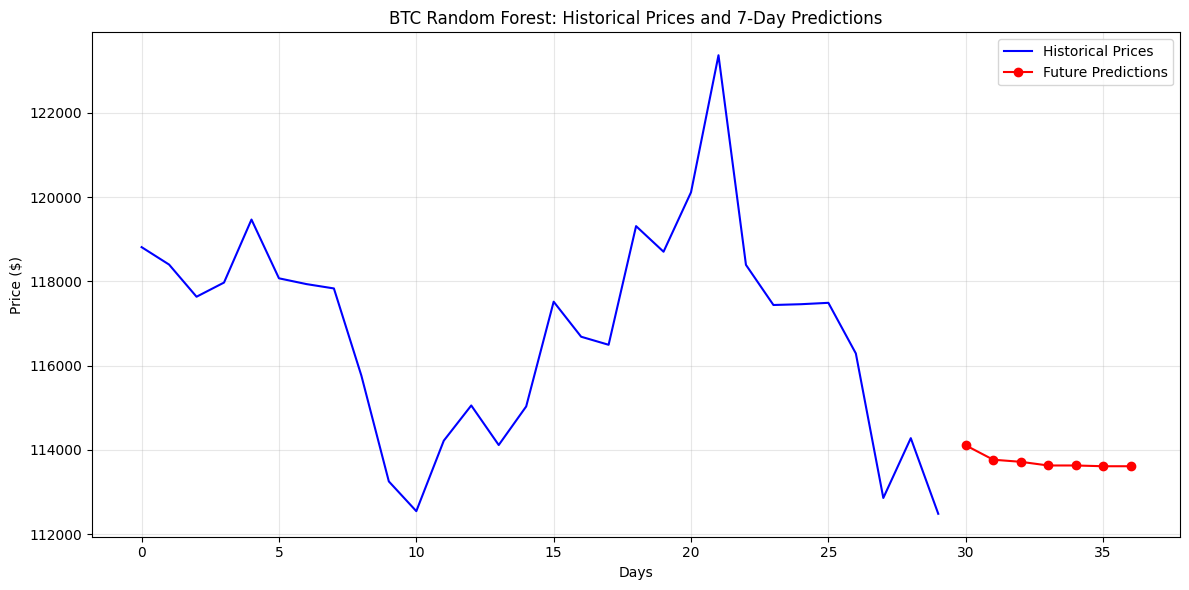

In [18]:
# Get the most recent data for prediction
print("Preparing data for future predictions...")

# We need to use the full original dataset (before train/test split) to get the most recent data
# The training data only goes up to -TEST_DAYS, so we need the complete dataset
full_data_original = pd.read_csv(fullDataPath(COIN))
full_data_original = full_data_original.loc[:, ~full_data_original.columns.str.contains('^Unnamed:')]
full_data_original = dataSetup(full_data_original, trainingColPath='../files/training_columns.txt')

# Filter to only the columns we used in training
full_data_original = full_data_original[training_cols + ['close']]

# We need to work with the raw price data to recalculate technical indicators
# Get the last 30 days of raw data to have enough for rolling calculations
recent_raw_data = full_data_original.tail(30).copy()
print(f"Starting predictions from the most recent date in dataset")
print(f"Most recent date: {recent_raw_data.tail(1).index[0]}")

# Prepare future predictions with rolling technical indicator updates
future_predictions = []
current_prices = recent_raw_data['close'].tolist()  # Keep track of prices for calculations

for day in range(TEST_DAYS):
    # Get the most recent data point
    current_row = recent_raw_data.tail(1).copy()

    # Update technical indicators based on current price history
    if len(current_prices) >= 7:
        # Update 7-day SMA
        current_row['SMA_7'] = np.mean(current_prices[-7:])

        # Update 7-day Volume MA (keep recent volume or use last known)
        recent_volumes = recent_raw_data['volume'].tail(7).tolist()
        current_row['Volume_MA_7'] = np.mean(recent_volumes)

        # Update Bollinger Bands (using 20-day period if available)
        if len(current_prices) >= 20:
            bb_period = 20
            bb_std = 2
            bb_sma = np.mean(current_prices[-bb_period:])
            bb_std_dev = np.std(current_prices[-bb_period:])
            current_row['BB_Lower'] = bb_sma - (bb_std_dev * bb_std)
            current_row['BB_Upper'] = bb_sma + (bb_std_dev * bb_std)

        # Update OBV (On Balance Volume) - simplified approach
        if day > 0:
            prev_close = current_prices[-2] if len(current_prices) >= 2 else current_prices[-1]
            current_close = current_prices[-1]
            volume = recent_raw_data['volume'].iloc[-1]
            prev_obv = recent_raw_data['OBV'].iloc[-1]

            if current_close > prev_close:
                current_row['OBV'] = prev_obv + volume
            elif current_close < prev_close:
                current_row['OBV'] = prev_obv - volume
            else:
                current_row['OBV'] = prev_obv

    # Normalize the features using the same scalers
    current_normalized = current_row.copy()

    # Get features to scale (excluding close) - use exact same columns as training
    features_to_normalize = current_row.drop(columns=['close']).columns
    features_in_scaler = [col for col in features_to_normalize if col in scaler.feature_names_in_]

    if features_in_scaler:
        current_normalized[features_in_scaler] = scaler.transform(current_row[features_in_scaler].values.reshape(1, -1))

    # Normalize close price
    current_normalized['close'] = closeScaler.transform(current_row[['close']].values.reshape(1, -1))[0]

    # Prepare input for prediction - use EXACT same structure as training
    current_X_norm = current_normalized.drop(columns=['close'])

    # Ensure columns are in the same order as training
    current_X_norm = current_X_norm[X_train_norm.columns]

    # Make prediction
    pred_normalized = best_rf.predict(current_X_norm)[0]

    # Inverse transform to get actual price
    pred_price = closeScaler.inverse_transform([[pred_normalized]])[0][0]

    future_predictions.append({
        'day': day + 1,
        'predicted_price': pred_price,
        'normalized_prediction': pred_normalized
    })

    # Add the predicted price to our price history for next iteration
    current_prices.append(pred_price)

    # Update the recent_raw_data with the new prediction for next iteration
    new_row = recent_raw_data.tail(1).copy()
    new_row['close'] = pred_price
    new_row['high'] = max(pred_price, new_row['high'].iloc[0])  # Update high
    new_row['low'] = min(pred_price, new_row['low'].iloc[0])    # Update low
    new_row.index = [recent_raw_data.index[-1] + pd.Timedelta(days=1)]  # Next day

    # Append to recent data and keep rolling window
    recent_raw_data = pd.concat([recent_raw_data, new_row]).tail(30)

# Create future predictions DataFrame
future_df = pd.DataFrame(future_predictions)

# Create directories if they don't exist
import os
os.makedirs(f'../predictions/{COIN}', exist_ok=True)

# Save predictions
predictions_save_path = f'../predictions/{COIN}/rf_predictions.csv'
print(f"\nFuture predictions saved to: {predictions_save_path}")

# Visualize future predictions
plt.figure(figsize=(12, 6))
recent_data = full_data_original.tail(30)  # Show last 30 days of actual data
plt.plot(range(len(recent_data)), recent_data['close'], label='Historical Prices', color='blue')

# Add future predictions
future_x = range(len(recent_data), len(recent_data) + len(future_df))
plt.plot(future_x, future_df['predicted_price'], label='Future Predictions', color='red', marker='o')
future_df.index = pd.date_range(start=recent_data.index[-1] + pd.Timedelta(days=1), periods=TEST_DAYS, freq='D')
future_df[['predicted_price']].to_csv(predictions_save_path, index=False)

plt.title(f'{COIN} Random Forest: Historical Prices and 7-Day Predictions')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7a. Save standardized RMSE to file (pipeline compliance)

In [19]:
# Ensure predictions directory exists
import os
os.makedirs(f'../predictions/{COIN}', exist_ok=True)

# Save standardized RMSE (computed on normalized scale) to a text file
rmse_path = f'../predictions/{COIN}/rf_standardized_rmse.txt'
with open(rmse_path, 'w') as f:
    f.write(f'{rmse:.6f}\n')
print(f'Standardized RMSE saved to: {rmse_path}')

Standardized RMSE saved to: ../predictions/BTC/rf_standardized_rmse.txt


# 8a. Save a 7-day forecast DataFrame with date index and predicted_price column

In [20]:
# Create DataFrame with date index and single column 'predicted_price'
try:
    future_df_indexed = future_df[['predicted_price']].copy()
    # Ensure index is the next 7 calendar days from the latest actual date
    if not isinstance(future_df_indexed.index, pd.DatetimeIndex) or len(future_df_indexed.index) != len(future_df_indexed):
        # Fallback: rebuild index if needed
        last_actual_date = full_data_original.index[-1] if isinstance(full_data_original.index, pd.DatetimeIndex) else pd.to_datetime(full_data_original.index[-1])
        future_df_indexed.index = pd.date_range(start=last_actual_date + pd.Timedelta(days=1), periods=TEST_DAYS, freq='D')
    future_df_indexed.index.name = 'date'

    # Save with index (dates) included
    future_predictions_indexed_path = f'../predictions/{COIN}/rf_future_predictions.csv'
    future_df_indexed.to_csv(future_predictions_indexed_path, index=True)
    print(f'Indexed 7-day forecast saved to: {future_predictions_indexed_path}')
except Exception as e:
    print('Failed to save indexed 7-day forecast:', e)


Indexed 7-day forecast saved to: ../predictions/BTC/rf_future_predictions.csv
